Step 4: KNN & Naïve Bayes
❖ Major Discussion
• K Nearest Neighbor
• Naïve Bayes

In [1]:
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

In [2]:
df = pd.read_csv('Diabetes_prediction.csv')

In [3]:
#select two features and 1 target column
x = df[["Pregnancies","BMI"]].values
y = df["Diagnosis"].values

Make the KNN and NB Graphs

In [8]:
# split the data in 80% train and 20% test
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2 ,random_state = 42)

In [10]:
#KNN MODEL INITIALIZE WITH K = 5
knn = KNeighborsClassifier(n_neighbors = 5)
knn.fit(x_train,y_train)

# predict using the KNN
y_pred_knn = knn.predict(x_test)
# calculate the accuracy
knn_accuracy = accuracy_score (y_test,y_pred_knn)

In [12]:
#INITIALIZE NAIVE BAYES MODEL
nb = GaussianNB()
nb.fit(x_train,y_train)
# predict using naive bayes
y_pred_nb = nb.predict(x_test)
#calculate naive bayes frequency
nb_accuracy =  accuracy_score(y_test,y_pred_nb)

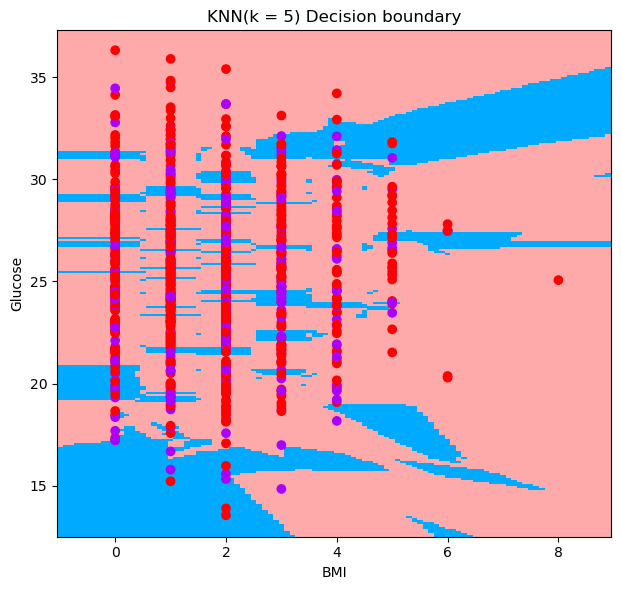

In [14]:
#meshgrid for ploting
x_min ,x_max = x[:,0].min() -1,x[:,0].max()+ 1
y_min ,y_max = x[:,1].min() -1,x[:,1].max()+ 1
xx ,yy = np.meshgrid(np.arange(x_min,x_max,0.1),np.arange(y_min,y_max ,0.1))

# color maps
cmap_l =ListedColormap(['#FFAAAA','#AAFFAA','#00AAFF']) # predicted
cmap_d =ListedColormap(['#FF0000','#00FF00','#AA00FF']) #  actual 

# MAKE KNN GRAPH
z_knn = knn.predict(np.c_[xx.ravel(),yy.ravel()])
z_knn = z_knn.reshape(xx.shape)

plt.figure(figsize =(12,6))
plt.subplot(1,2,1)
plt.pcolormesh(xx ,yy , z_knn ,cmap = cmap_l)
plt.scatter(x[:,0],x[:,1], c = y, cmap = cmap_d)
plt.title("KNN(k = 5) Decision boundary")
plt.xlabel('BMI')
plt.ylabel('Glucose')

plt.tight_layout()
plt.show()

#interpretation
It is challenging for the model to distinguish between the two classes due to the substantial overlap between the KNN decision border for BMI and glucose. The ragged border implies that KNN has trouble with these characteristics, suggesting that they might not be enough on their own to provide an appropriate categorization. Model performance could be enhanced by adding more features or changing the number of neighbors.

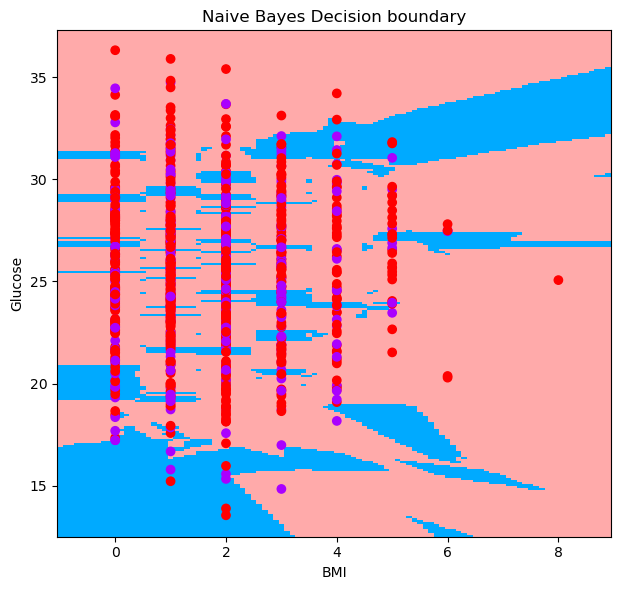

In [19]:
# NAIVE BAYES 
z_knn = knn.predict(np.c_[xx.ravel(),yy.ravel()])
z_knn = z_knn.reshape(xx.shape)

plt.figure(figsize =(12,6))
plt.subplot(1,2,1)
plt.pcolormesh(xx ,yy , z_knn ,cmap = cmap_l)
plt.scatter(x[:,0],x[:,1], c = y, cmap = cmap_d)
plt.title("Naive Bayes Decision boundary")
plt.xlabel('BMI')
plt.ylabel('Glucose')

plt.tight_layout()
plt.show()

interpretation
A smoother but still overlapping decision border is produced by Naive Bayes with Pregnancies and Glucose features, suggesting that these two characteristics by themselves are insufficient for efficient classification. Results could be enhanced with more features or sophisticated models.

Find the accuracy of both models

In [23]:
print(f"KNN Accuracy : {knn_accuracy:2f}")
print(f"Naive Bayes Accuracy : {nb_accuracy:2f}")

KNN Accuracy : 0.630000
Naive Bayes Accuracy : 0.685000


With an accuracy of 68.5%, the Naive Bayes model outperformed the K-Nearest Neighbors (KNN) model, which had an accuracy of 62.0%. This suggests that Naive Bayes, probably because it is probabilistic, works better with  dataset. Hyperparameter adjustment and feature scaling may help KNN, but Naive Bayes' ease of use and marginally better performance may make it the better choice. 

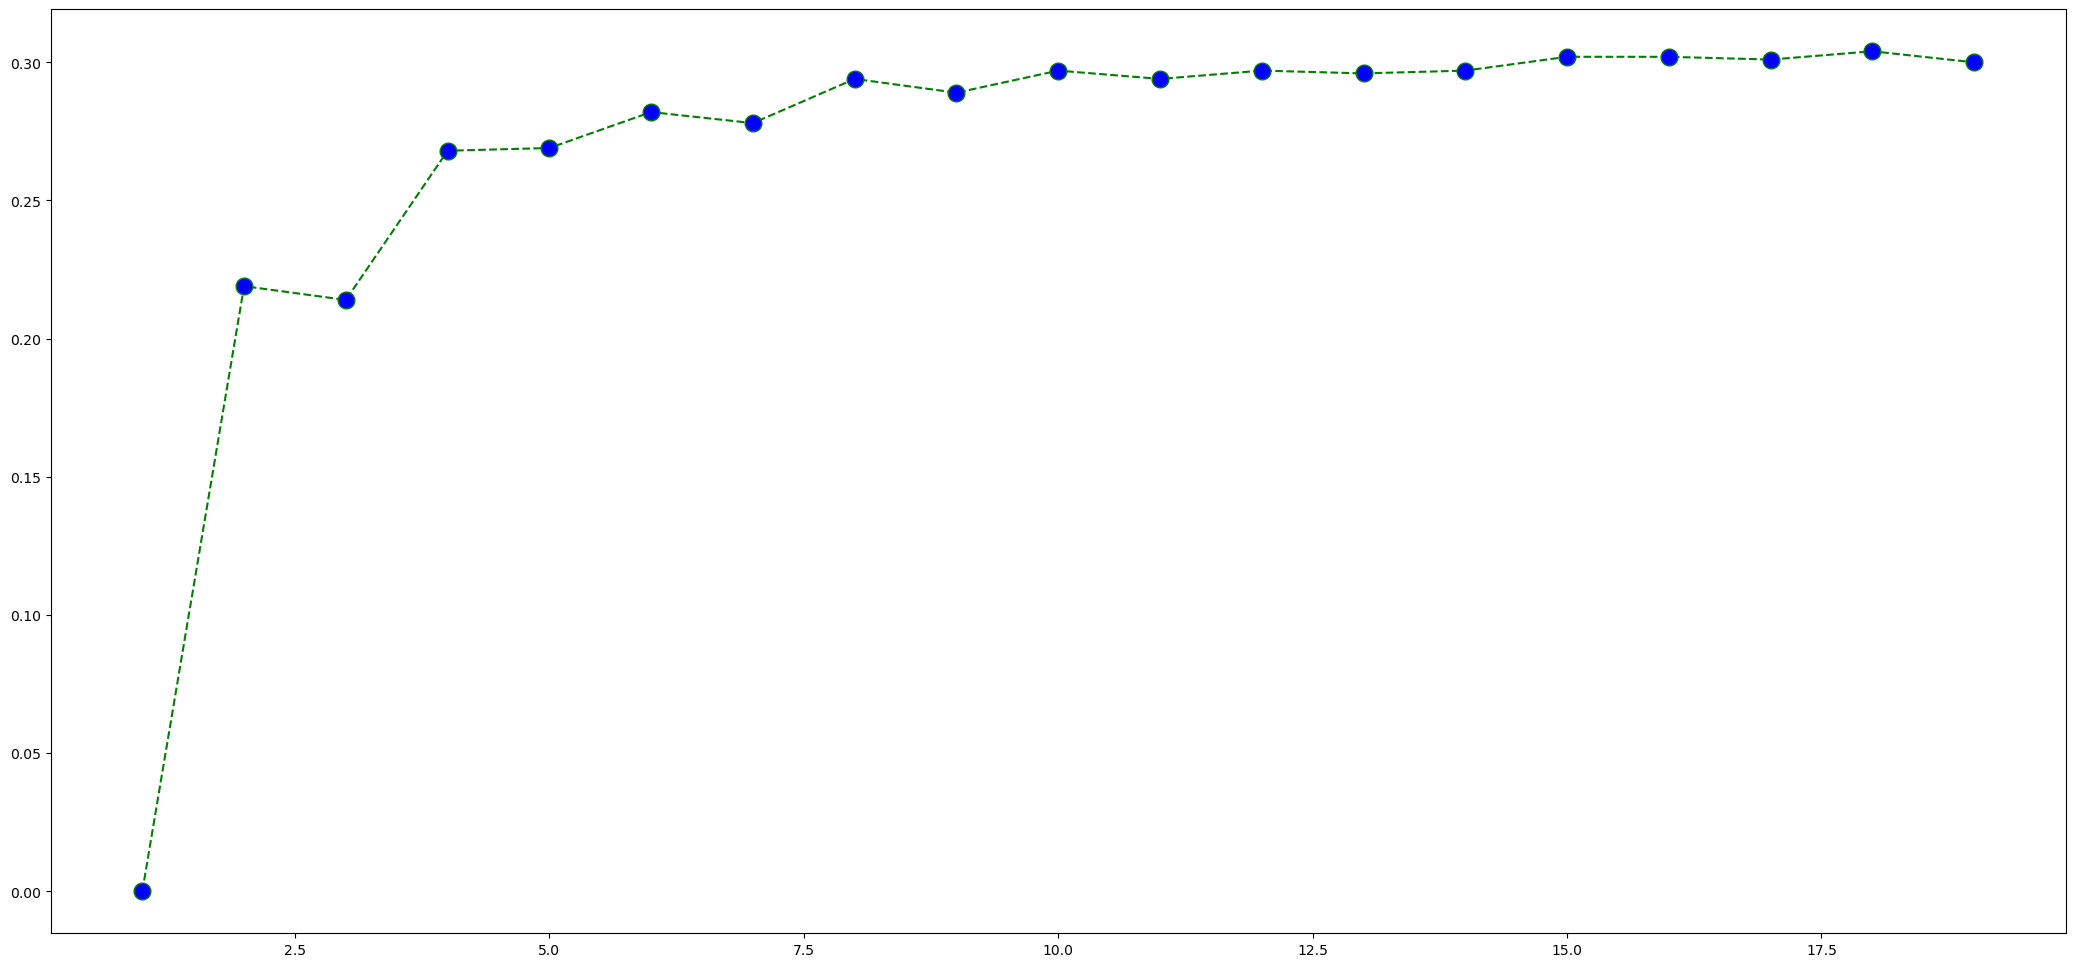

In [26]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

SSE=[]
for k in range(1,20):
    knn=KNeighborsClassifier(n_neighbors=k)
    knn.fit(x,y)
    pred_i=knn.predict(x)
    SSE.append(np.mean(pred_i != y))
plt.figure(figsize=(26,12))
plt.plot(range(1,20),SSE,color='g',linestyle='dashed',marker='o',markerfacecolor='b',markersize=12)
plt.show()

In [28]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Diagnosis
0,2,115.863387,56.410731,24.336736,94.385783,26.455940,0.272682,20.100494,0
1,2,92.490122,70.615520,23.443591,138.652426,23.910167,0.665160,44.912281,0
2,1,88.141469,63.262618,23.404364,149.358082,21.948250,0.676022,48.247873,1
3,2,108.453101,67.793632,20.751580,108.751638,24.209304,0.289636,42.749868,0
4,1,127.849443,94.725685,22.603078,25.269987,32.997477,0.601315,32.797789,0


KNN Accuracy: 0.6200
Naive Bayes Accuracy: 0.6933


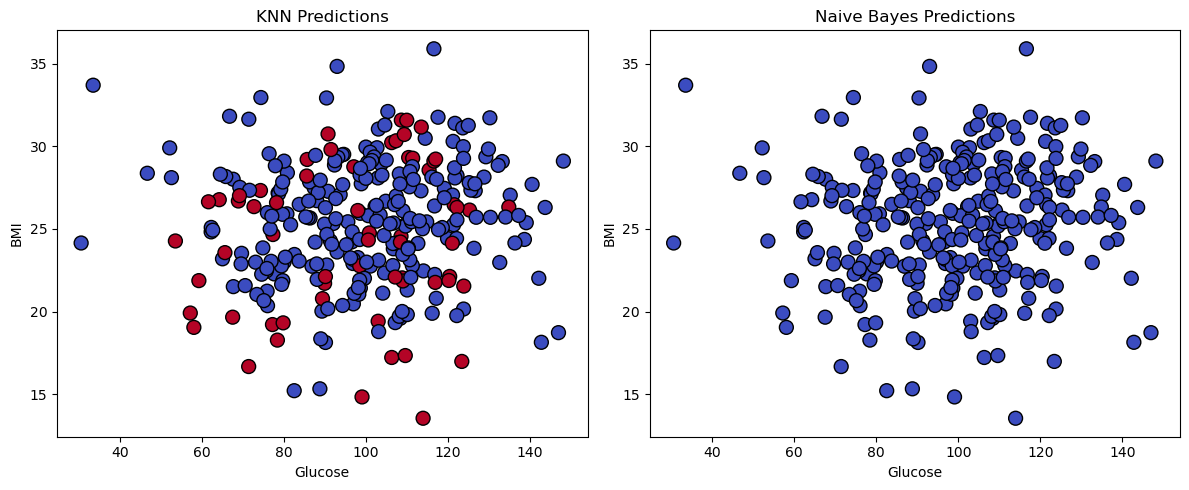

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# Load the dataset
data = pd.read_csv('Diabetes_prediction.csv')

# Select features and target
features = data[['Glucose', 'BMI']]
target = data['Diagnosis']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.3, random_state=42)

# Standardize the features for KNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# KNN Model
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
knn_pred = knn_model.predict(X_test_scaled)

# Naive Bayes Model
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)  # No scaling for Naive Bayes
nb_pred = nb_model.predict(X_test)

# Calculate accuracy
knn_accuracy = accuracy_score(y_test, knn_pred)
nb_accuracy = accuracy_score(y_test, nb_pred)

# Print accuracy
print(f'KNN Accuracy: {knn_accuracy:.4f}')
print(f'Naive Bayes Accuracy: {nb_accuracy:.4f}')

# Plotting
plt.figure(figsize=(12, 5))

# KNN plot
plt.subplot(1, 2, 1)
plt.scatter(X_test['Glucose'], X_test['BMI'], c=knn_pred, cmap='coolwarm', edgecolor='k', s=100)
plt.title('KNN Predictions')
plt.xlabel('Glucose')
plt.ylabel('BMI')

# Naive Bayes plot
plt.subplot(1, 2, 2)
plt.scatter(X_test['Glucose'], X_test['BMI'], c=nb_pred, cmap='coolwarm', edgecolor='k', s=100)
plt.title('Naive Bayes Predictions')
plt.xlabel('Glucose')
plt.ylabel('BMI')

plt.tight_layout()
plt.show()


For this dataset, Naive Bayes performs better because of greater accuracy of 69.33% as opposed to 62.00% for KNN
Though the decision boundary is simpler, it is more efficient.
Improved generality in spite of cautious forecasts

However, crucial factors should take into account:

The accuracy of both is moderate (less than 70%).
Results could be enhanced by using different algorithms or feature engineering.
Whether reducing false positives or false negatives is more crucial for the particular application may determine the final model selection.

In conclusion, based on accuracy, Naive Bayes is the superior option in this case; however, total model performance might be enhanced.


Comparing Models
Naive Bayes performs better on this dataset, with an accuracy of 69.3%, than KNN, which attained an accuracy of 62%, according to the published accuracies.

## conclusion
The greater accuracy of the Naive Bayes model raises the possibility that it is better able to identify the underlying patterns in the data pertaining to the diabetes classification. Its probabilistic nature and feature independence requirements may be the cause of this, as they may fit in nicely with the dataset's properties. More indicators, like precision, recall, and F1-score, may offer deeper insights into model performance if more research or model modification is required.